In [ ]:
# =========================================================
# 📦 Cell 1 – Environment & Drive mount
# =========================================================
import sys, subprocess, json, math, os, random, time
import torch, torchvision

# Mount Google Drive (uncomment next line if not already mounted)
from google.colab import drive
drive.mount('/content/drive')

# Upgrade/Install (restart runtime after this cell if torch/torchvision were updated)
!pip install -q --upgrade torch torchvision torchmetrics timm


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# 🗑️ Cell – one-time cleanup
!pip uninstall -y torchaudio fastai


In [ ]:
# =========================================================
# ⚙️ Cell 2 – Imports & Config
# =========================================================
import torch
from torch import nn, optim
from torchvision import transforms, datasets, models
from torch.utils.data import DataLoader
from torchmetrics.classification import MulticlassAccuracy
from tqdm import tqdm

DATA_DIR = "/content/drive/MyDrive/PS-1/dataset"
NUM_CLASSES = 14
BATCH_SIZE  = 32
EPOCHS      = 20
LR          = 3e-4
IMG_SIZE    = 224          # MobileNetV3 default
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED        = 42
torch.manual_seed(SEED); random.seed(SEED)

print("Using", DEVICE)


Using cuda


In [ ]:
# =========================================================
# 🚚  Cell – Fast local copy (runs only once per session)
# =========================================================
import shutil, os, pathlib, time, math

DRIVE_DATA_DIR = "/content/drive/MyDrive/PS-1/dataset"
LOCAL_DATA_DIR = "/content/dataset"                 # <-- new, faster path

if not pathlib.Path(LOCAL_DATA_DIR).exists():
    t0 = time.time()
    print("🔄  Copying dataset from Drive → local SSD …")
    shutil.copytree(DRIVE_DATA_DIR, LOCAL_DATA_DIR)
    print(f"✅  Done in {time.time() - t0:.1f} s")
else:
    print("📂  Local dataset already exists — skipping copy.")

DATA_DIR = LOCAL_DATA_DIR     # <<-- overwrite the global used later


🔄  Copying dataset from Drive → local SSD …
✅  Done in 144.7 s


In [ ]:
# =========================================================
# 🗂️  Cell 2½ – One-time 80-20 train/val folder split
#          (runs only if 'train' & 'val' do NOT exist)
# =========================================================
import pathlib, shutil, random, os

root      = pathlib.Path(DATA_DIR)            # /content/drive/MyDrive/PS-1/dataset
train_dir = root / "train"
val_dir   = root / "val"

if not train_dir.exists() and not val_dir.exists():
    print("🔧  First run: creating train/val split (80-20)…")
    for cls_dir in sorted([d for d in root.iterdir() if d.is_dir()]):
        if cls_dir.name in ["train", "val"]:        # skip if user already has these
            continue

        images = list(cls_dir.glob("*"))
        if len(images) == 0:                        # skip empty folders
            continue

        random.shuffle(images)
        n_val = int(0.2 * len(images))

        # Create destination folders
        (train_dir / cls_dir.name).mkdir(parents=True, exist_ok=True)
        (val_dir   / cls_dir.name).mkdir(parents=True, exist_ok=True)

        for i, img_path in enumerate(images):
            dest = val_dir / cls_dir.name if i < n_val else train_dir / cls_dir.name
            shutil.move(str(img_path), dest)

        # Remove the now-empty original class folder
        try:
            cls_dir.rmdir()
        except OSError:
            pass

    print("✅  Split complete!")
else:
    print("📂  train/val folders already present — skipping split.")


📂  train/val folders already present — skipping split.


In [ ]:
# =========================================================
# 🖼️  Cell – Augmented DataLoaders (v2)
# =========================================================
from torchvision import transforms, datasets
from torch.utils.data import DataLoader

NUM_WORKERS = 2           # ↑ if Colab gives ≥4 vCPUs
PIN_MEMORY  = True
IMG_SIZE    = 224         # keep consistent with model

mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

train_tfms = transforms.Compose([
    # --- geometric ---
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.5, 1.2), ratio=(0.75, 1.33)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomAffine(
        degrees=20,          # rotation
        translate=(0.15,0.15),
        scale=(0.7, 1.3),
        shear=10,
        interpolation=transforms.InterpolationMode.BILINEAR,
        fill=0),
    transforms.RandomPerspective(distortion_scale=0.4, p=0.3),

    # --- photometric ---
    transforms.ColorJitter(0.3, 0.3, 0.3, 0.15),
    transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 2.0)),

    transforms.ToTensor(),
    transforms.RandomErasing(p=0.25, scale=(0.02,0.15), ratio=(0.3,3.3), value='random'),
    transforms.Normalize(mean, std),
])

val_tfms = transforms.Compose([
    transforms.Resize(IMG_SIZE + 32),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

train_ds = datasets.ImageFolder(f"{DATA_DIR}/train", transform=train_tfms)
val_ds   = datasets.ImageFolder(f"{DATA_DIR}/val",   transform=val_tfms)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
    persistent_workers=True)

val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
    persistent_workers=True)

print(f"Train images: {len(train_ds)}   |   Val images: {len(val_ds)}")


Train images: 11390   |   Val images: 2842


In [ ]:
# =========================================================
# 🧠 Cell 4 – Model Definition (MobileNet V3 Large + custom head)
# =========================================================
model = models.mobilenet_v3_large(weights="MobileNet_V3_Large_Weights.IMAGENET1K_V2")
# Replace classifier
model.classifier[3] = nn.Linear(model.classifier[3].in_features, NUM_CLASSES)
model.to(DEVICE)

# Loss + optimizer + metric
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
metric    = MulticlassAccuracy(num_classes=NUM_CLASSES).to(DEVICE)


In [ ]:
# =========================================================
# 🚂 NEW Cell 5 – Robust Training Loop with Checkpoints
# =========================================================
import pathlib, re

CKPT_DIR   = pathlib.Path("/content/drive/MyDrive/PS-1/checkpoints")
CKPT_DIR.mkdir(parents=True, exist_ok=True)

# -------- Utility: find latest checkpoint --------
def get_latest_ckpt(ckpt_dir):
    ckpts = sorted(ckpt_dir.glob("epoch-*.pth"),
                   key=lambda p: int(re.findall(r"epoch-(\d+)", p.name)[0]))
    return ckpts[-1] if ckpts else None

latest_ckpt = get_latest_ckpt(CKPT_DIR)
start_epoch  = 1
best_acc     = 0.0

if latest_ckpt:
    print(f"🔄  Resuming from {latest_ckpt.name}")
    saved = torch.load(latest_ckpt, map_location=DEVICE)
    model.load_state_dict(saved["model_state_dict"])
    optimizer.load_state_dict(saved["optimizer_state_dict"])
    best_acc    = saved["best_acc"]
    start_epoch = saved["epoch"] + 1

# -------- Training & Validation functions (unchanged) --------
def train_epoch(model, loader):
    model.train(); running_loss = 0; metric.reset()
    for x, y in tqdm(loader, leave=False):
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        preds = model(x)
        loss  = criterion(preds, y)
        loss.backward(); optimizer.step()
        running_loss += loss.item() * x.size(0)
        metric.update(preds, y)
    return running_loss / len(loader.dataset), metric.compute().item()

@torch.no_grad()
def valid_epoch(model, loader):
    model.eval(); running_loss = 0; metric.reset()
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        preds = model(x)
        loss  = criterion(preds, y)
        running_loss += loss.item() * x.size(0)
        metric.update(preds, y)
    return running_loss / len(loader.dataset), metric.compute().item()

# -------- Main loop with always-on checkpointing --------
try:
    for epoch in range(start_epoch, EPOCHS + 1):
        train_loss, train_acc = train_epoch(model, train_loader)
        val_loss,   val_acc   = valid_epoch(model, val_loader)

        print(f"[{epoch:02d}/{EPOCHS}] "
              f"train {train_acc*100:5.1f}%/{train_loss:.3f}  |  "
              f"val {val_acc*100:5.1f}%/{val_loss:.3f}")

        # Save snapshot every epoch
        snapshot = {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "best_acc": best_acc,
        }
        torch.save(snapshot, CKPT_DIR / f"epoch-{epoch:03d}.pth")

        # Save best model separately
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), CKPT_DIR / "best.pth")

except KeyboardInterrupt:
    # Graceful exit on Colab disconnect or manual stop
    print("\n⏹️  Interrupted — saving last state …")
    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "best_acc": best_acc,
    }, CKPT_DIR / f"epoch-{epoch:03d}-INT.pth")
    print("✅  Checkpoint saved. You can safely reconnect and resume.")


[01/20] train  79.5%/0.613  |  val  98.0%/0.063


[02/20] train  92.0%/0.240  |  val  98.7%/0.038



⏹️  Interrupted — saving last state …
✅  Checkpoint saved. You can safely reconnect and resume.


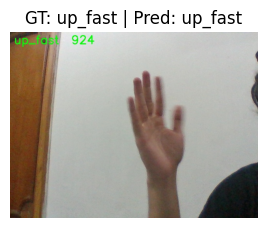

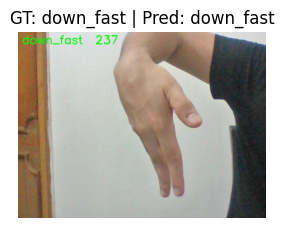

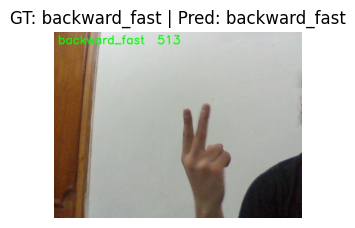

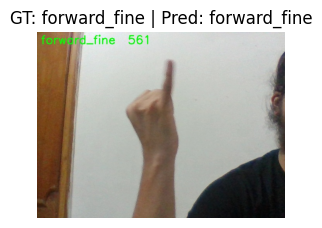

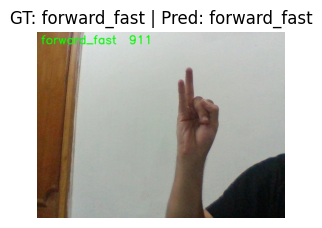

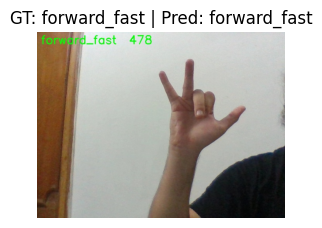

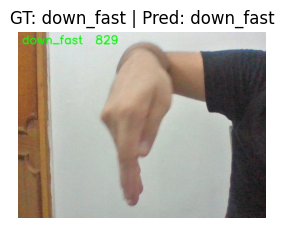

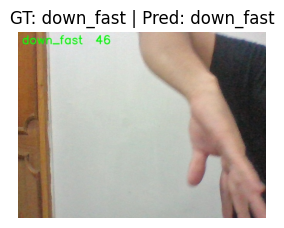

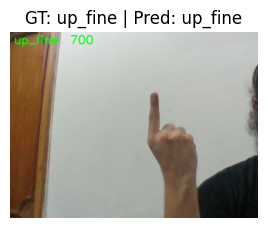

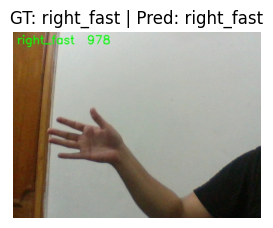

In [ ]:
# =========================================================
# 🔍 Random sample (10) from val/ and predict
# =========================================================
import random, pathlib, torch
import matplotlib.pyplot as plt
from PIL import Image

model.eval()                     # ← make sure we’re in eval mode
N_SAMPLES = 10                   # change if you want more/less

# Get N_SAMPLES random indices from the validation dataset
sample_indices = random.sample(range(len(val_ds)), k=N_SAMPLES)

for i, idx in enumerate(sample_indices, 1):
    img_path, true_label = val_ds.samples[idx]   # (path, class-idx)
    img = Image.open(img_path).convert("RGB")

    x = val_tfms(img).unsqueeze(0).to(DEVICE)    # same val_tfms as before
    with torch.no_grad():
        pred_idx = torch.softmax(model(x), dim=1).argmax(dim=1).item()

    # -------- display ----------
    plt.figure(figsize=(3.2, 3.2))
    plt.title(f"GT: {val_ds.classes[true_label]} | "
              f"Pred: {val_ds.classes[pred_idx]}")
    plt.imshow(img); plt.axis("off")
plt.show()


Predicted: up_fine


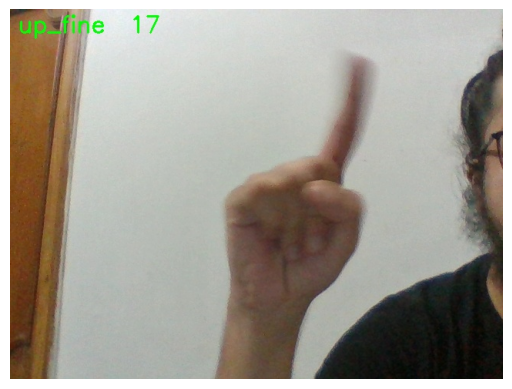

In [ ]:
# =========================================================
# 🔍 Cell 6 – Quick Inference on a Single Image
# =========================================================
from PIL import Image
import matplotlib.pyplot as plt

def predict(path):
    img = Image.open(path).convert("RGB")
    x   = val_tfms(img).unsqueeze(0).to(DEVICE)
    model.eval()
    pred = torch.softmax(model(x), dim=1).argmax(dim=1).item()
    print("Predicted:", train_ds.classes[pred])
    plt.imshow(img); plt.axis("off")

# Example — change filename accordingly

predict("/content/drive/MyDrive/PS-1/dataset/val/up_fine/up_fine_0017.jpg")


               precision    recall  f1-score   support

backward_fast      0.995     1.000     0.998       204
backward_fine      1.000     1.000     1.000       203
    down_fast      1.000     1.000     1.000       206
    down_fine      1.000     0.975     0.988       203
 forward_fast      1.000     0.985     0.993       203
 forward_fine      1.000     0.990     0.995       204
    left_fast      1.000     1.000     1.000       205
    left_fine      1.000     1.000     1.000       202
      neutral      0.976     0.995     0.986       205
       pickup      0.985     1.000     0.993       200
   right_fast      1.000     1.000     1.000       202
   right_fine      0.985     1.000     0.993       202
      up_fast      0.995     1.000     0.998       200
      up_fine      1.000     0.990     0.995       203

     accuracy                          0.995      2842
    macro avg      0.995     0.995     0.995      2842
 weighted avg      0.995     0.995     0.995      2842



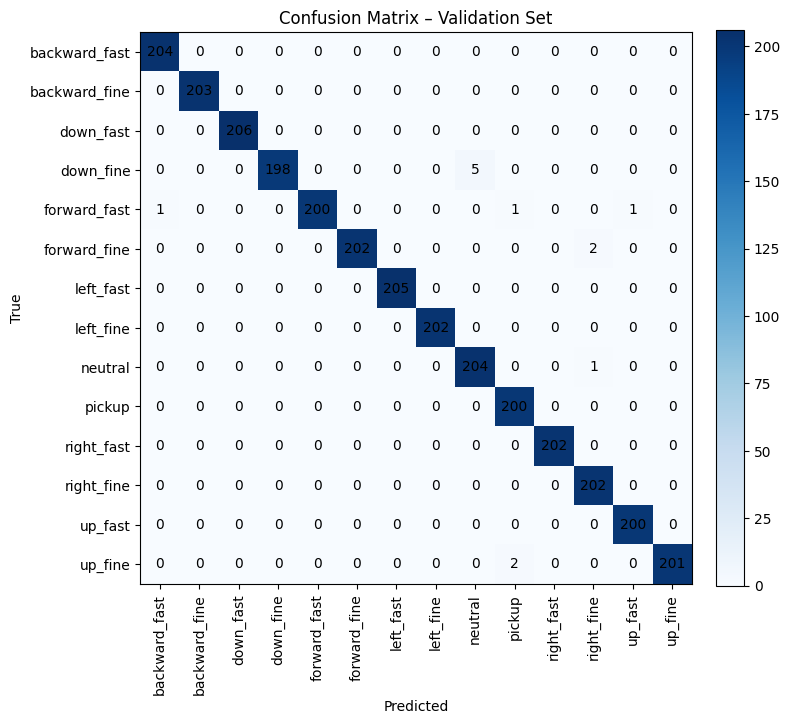

In [ ]:
# =========================================================
# 📊  Confusion matrix & classification report on val set
# =========================================================
import numpy as np, torch, matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for x, y in val_loader:
        preds = torch.softmax(model(x.to(DEVICE)), dim=1).argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
report = classification_report(all_labels, all_preds,
                               target_names=val_ds.classes, digits=3)
print(report)

# ---------- nice visual ----------
fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(np.arange(len(val_ds.classes)))
ax.set_yticks(np.arange(len(val_ds.classes)))
ax.set_xticklabels(val_ds.classes, rotation=90)
ax.set_yticklabels(val_ds.classes)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Confusion Matrix – Validation Set")

# annotate each cell
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="black")

plt.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


In [ ]:
# =========================================================
# 💾 Cell 7 – Export to ONNX (optional for deployment)
# =========================================================
dummy_input = torch.randn(1, 3, IMG_SIZE, IMG_SIZE, device=DEVICE)
model.load_state_dict(torch.load("/content/drive/MyDrive/PS-1/checkpoints_1/best.pth", map_location=DEVICE))
model.eval()

torch.onnx.export(
    model, dummy_input, "/content/mobilenetv3_gestures.onnx",
    input_names=["input"], output_names=["logits"],
    opset_version=13, dynamic_axes={"input": {0:"batch"}, "logits": {0:"batch"}}
)
print("ONNX model saved.")


OnnxExporterError: Module onnx is not installed!

In [ ]:
print(train_ds.classes)          # or val_ds.classes – they’re identical


['backward_fast', 'backward_fine', 'down_fast', 'down_fine', 'forward_fast', 'forward_fine', 'left_fast', 'left_fine', 'neutral', 'pickup', 'right_fast', 'right_fine', 'up_fast', 'up_fine']
